# Analysis of wavefront sensor data from ALS 5.3.1

Author: Wei "Francis" He (francisho@lbl.gov / whorwhey@gmail.com)

Created: May 2026 · Last updated: 2026-05-29

Based on earlier work with Dr. Antoine Islegen-Wojdyla.

___

## Overview

Template notebook for reconstructing the BL 5.3.1 beam wavefront from shearing interferograms acquired via Bluesky scans on the Tiled server. Loads a scan, picks one frame, and runs the `wfs_live` pipeline end-to-end.

### Conventions

- All physical quantities in SI units (suffix `_m`, `_s`, `_eV`).
- Wavefronts in radians internally; plotted in nm via λ/(2π).



# SETUP 

## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tiled.client import from_uri

In [2]:
import wfs_live as wfl

## Access Data from the Server


In [3]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

> **Tiled version note:** `tiled == 0.2.9` failed; pin to `0.2.1` until verified otherwise.


__Available scans:__

- `Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'` — grid scan, **2026-04-01**:  
  `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`
- `Uid = '337b4bd2-30ef-42bd-812d-223390cb860f'` — grid scan, **2026-05-28**:  
  `RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1200, 9, snake_axes=False))`

### Load data for 2026-04-01 scan (archived)

In [15]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm  (binning: 1x1×)
Effective pixel: 0.48 µm
Exposure time:   0.75 s
WFS chip position (mm): [9.200158 9.200158]


In [16]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

Images shape: (76, 3672, 800)  (n_frames × height × width)
Energy range: 6999.8 – 9999.8 eV
       shape: (77,)
Bender range: -2000.0 – -0.0 µm
       shape: (77,)


In [17]:
start = db.metadata['start']
cam   = db['primary'].metadata['configuration']['basler_5472']['data']

# --- From device configuration (ground truth) ---
exp_time_cfg     = cam['basler_5472_cam_acquire_time']
camera_model_cfg = cam['basler_5472_cam_model']

# --- From md (what was typed) ---
exp_time_md      = start.get('exposure time [s]')
camera_model_md  = start.get('camera model')

print("Exposure time:  config =", exp_time_cfg,   "| md =", exp_time_md,
      "| match:", exp_time_cfg == exp_time_md)
print("Camera model:   config =", camera_model_cfg, "| md =", camera_model_md,
      "| match:", camera_model_cfg == camera_model_md)

Exposure time:  config = 0.75 | md = 0.75 | match: True
Camera model:   config = acA5472-5gm | md = acA5472-5gm | match: True


### Load data: Current (from 2026-05-28) 

Example of scans:

```python
# --- Descriptive metadata: ONLY things the hardware can't report ---
md = {
    'pixel size [um]': 2.4,                          # sensor pixel pitch (datasheet)
    'binning': '1x1',
    'effective pixel size [um]': 0.48,               # pixel_size / objective magnification
    'objective model': 'Mitutoyo Plan Apo HR 5X',   
}

# Scan energy x bender, recording a camera image at each point.
# energy and bender are SCANNED -> they become per-point DATA columns.
RE(grid_scan(
    [basler_5472],
    mono_energy, 7000, 10000, 7,
    Obender,     -2000, 0, 11,
    snake_axes=False,
    md=md,
))
```

__Note:__ In `md`, deliberately NOT setting 'exposure time [s]' or 'camera model' -- those are read-back from device configuration (ground truth).

In [5]:
# --- Dataset ---
DATASET_ID = '337b4bd2-30ef-42bd-812d-223390cb860f'
db = tiled_client[DATASET_ID]

# Metadata: Hardware-reported; stored in config
cam   = db['primary'].metadata['configuration']['basler_5472']['data']
exp_time_s   = cam['basler_5472_cam_acquire_time']
camera_model = cam['basler_5472_cam_model']

# Descriptive (from md; .get())
start = db.metadata['start']
pixel_size_um           = start.get('pixel size [um]')
binning                 = start.get('binning')
effective_pixel_size_um = start.get('effective pixel size [um]')
objective_model         = start.get('objective model')

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning})")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")


Camera:          acA5472-5gm
Objective:       None
Pixel size:      None µm  (binning: None)
Effective pixel: None µm
Exposure time:   2.0 s


In [6]:
# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")


WFS chip position (mm): [4.400054 4.400054]

Images shape: (99, 3672, 2000)  (n_frames × height × width)
Energy range: 6999.8 – 9000.0 eV
       shape: (99,)
Bender range: -2000.0 – -1200.0 µm
       shape: (99,)


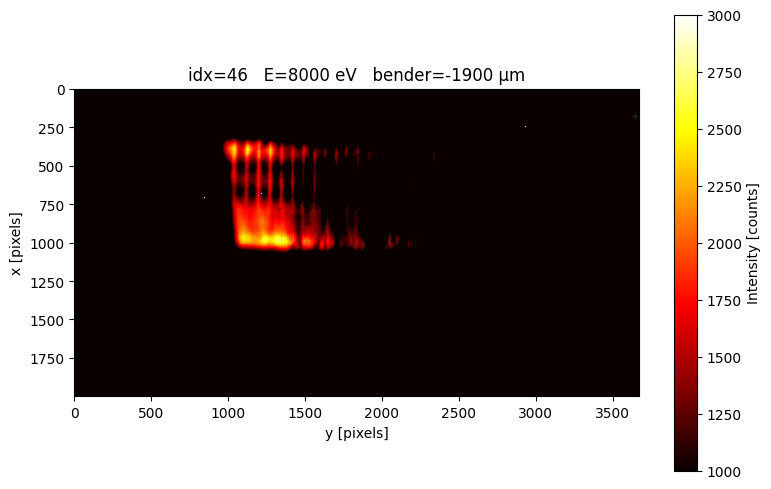

In [18]:
# Pick one frame as proof of life
idx = 46

plt.figure(figsize=(8, 5))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmin = 1000,vmax=3000)
plt.title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[idx]:.0f} µm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

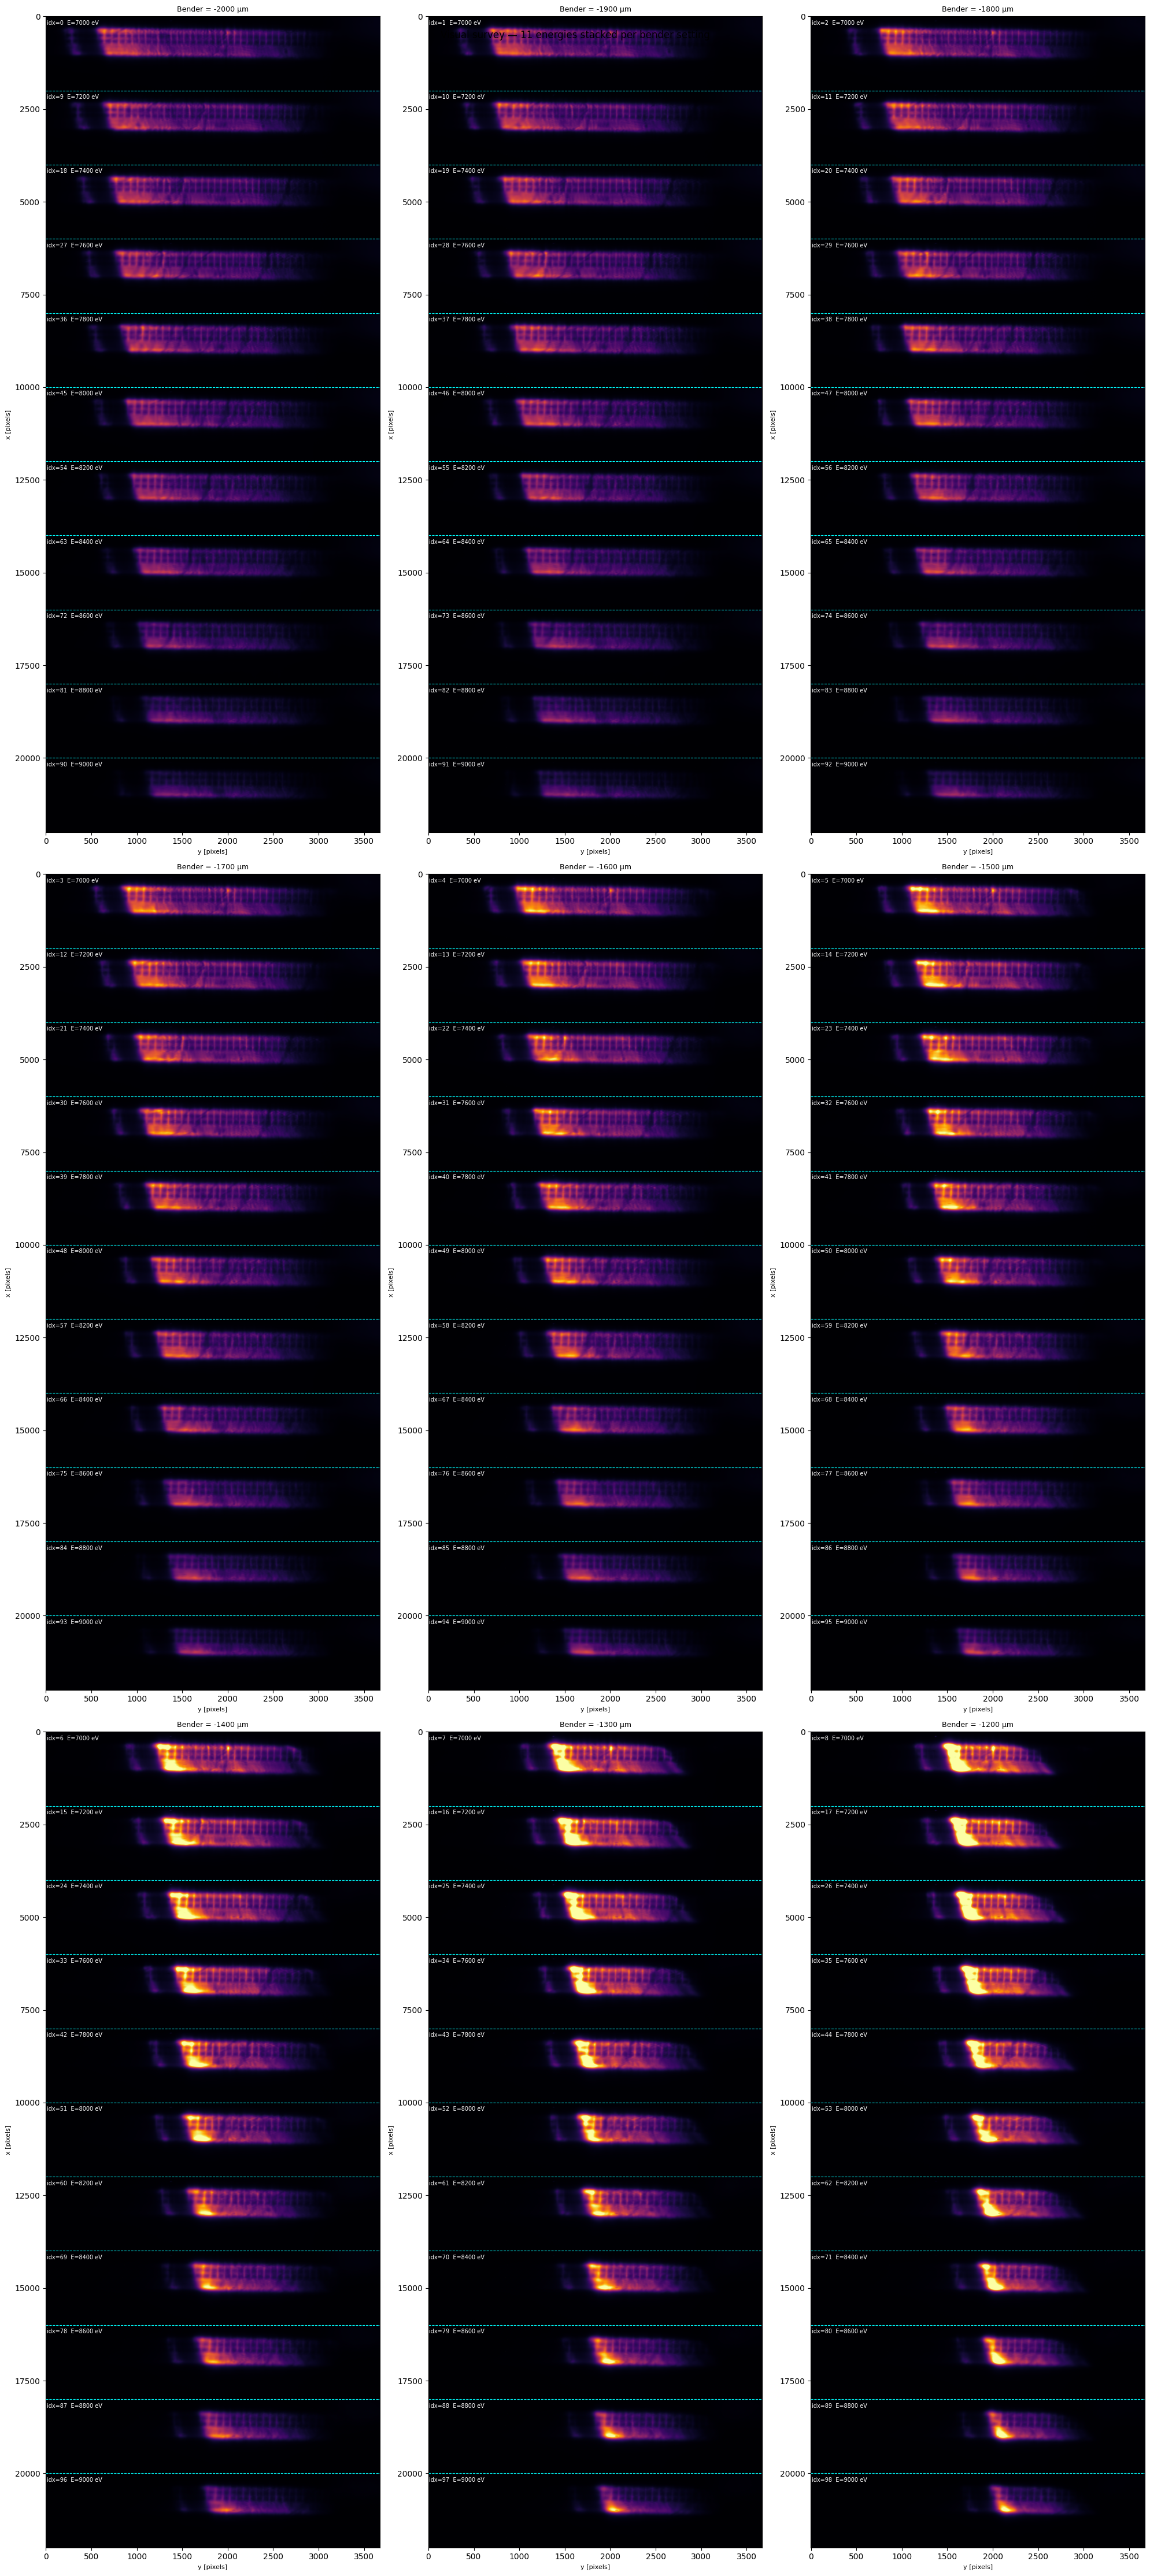

In [15]:
# Visual survey — 11 energies stacked per bender (~10 seconds)

fig, axes = plt.subplots(3, 3, figsize=(20, 45))
axes = axes.ravel()

for b in range(9):
    ax       = axes[b]
    idx_list = [e*9 + b for e in range(11)]
    panels   = [images[idx].T for idx in idx_list]
    stacked  = np.vstack(panels)
    n_y      = panels[0].shape[0]

    ax.imshow(stacked, cmap='inferno', aspect='auto', vmax=4000)

    for k in range(1, len(idx_list)):
        ax.axhline(k * n_y - 0.5, color='cyan', linewidth=0.8, linestyle='--')

    for k, idx in enumerate(idx_list):
        ax.text(10, k * n_y + n_y * 0.05,
                f'idx={idx}  E={energy_eV[idx]:.0f} eV',
                color='white', fontsize=7, va='top')

    ax.set_title(f'Bender = {bender_um[b]:.0f} µm', fontsize=9)
    ax.set_xlabel('y [pixels]', fontsize=8)
    ax.set_ylabel('x [pixels]', fontsize=8)

fig.suptitle('Visual survey — 11 energies stacked per bender setting', fontsize=12)
plt.tight_layout()
plt.show()

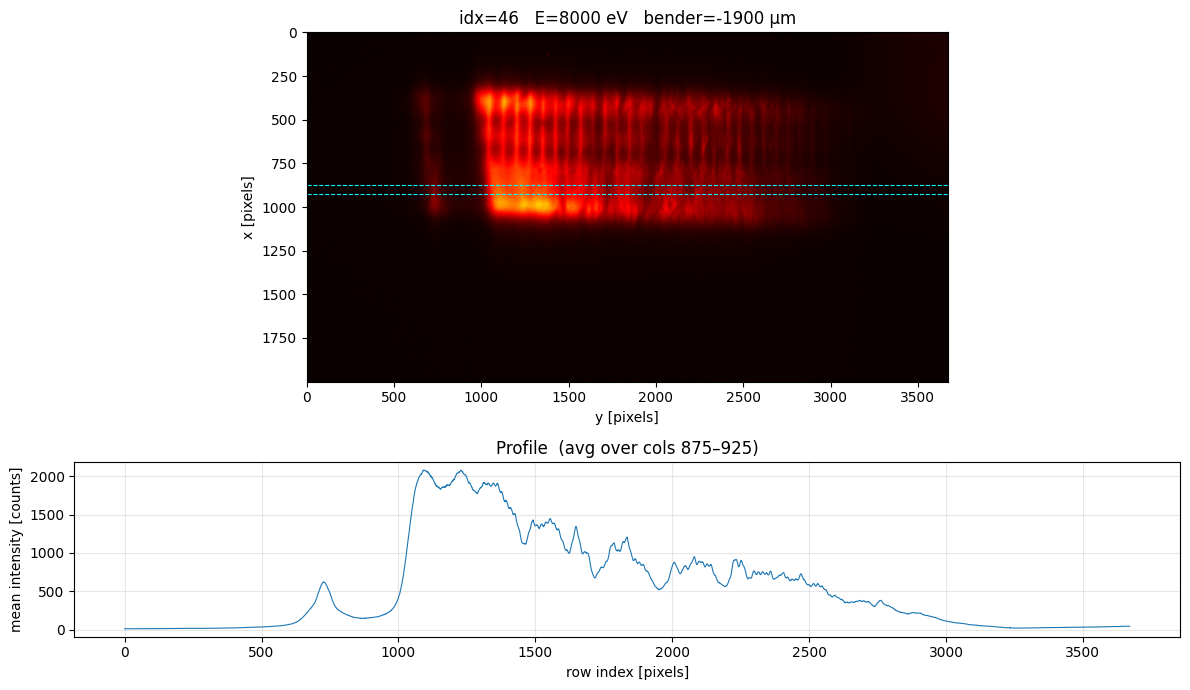

In [21]:
idx = 46
y_roi = slice(875, 925)
axis  = 1

profile = wfl.extract_profile(images[idx], y_roi, axis=axis)

fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={'height_ratios': [2, 1]})

# Image with ROI band
axes[0].imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
axes[0].axhline(y_roi.start, color='cyan', lw=0.8, ls='--')
axes[0].axhline(y_roi.stop,  color='cyan', lw=0.8, ls='--')
axes[0].set_title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[idx]:.0f} µm')
axes[0].set_xlabel('y [pixels]')
axes[0].set_ylabel('x [pixels]')

# 1-D profile
axes[1].plot(profile, lw=0.8)
axes[1].set_xlabel('row index [pixels]')
axes[1].set_ylabel('mean intensity [counts]')
axes[1].set_title(f'Profile  (avg over cols {y_roi.start}–{y_roi.stop})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# RECON


In [ ]:
# Test A: quick_look (no propagation)
r_quick = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    title='Test A — quick_look (no propagation)',
)

In [ ]:
# Test B: quick_look with propagation
r_quick_prop = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    title='Test B — quick_look (with propagation)',
)

In [ ]:
# Test C: reconstruct_single + plot_result separately
# Shows the manual two-step workflow that quick_look wraps
r_manual = wfl.reconstruct_single(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    verbose=True,
)
wfl.plot_result(r_manual, title='Test C — reconstruct_single + plot_result')

# Confirm B and C give identical numbers
print("\n─── Self-consistency check (B vs C) ───")
print(f"f_pred     B={r_quick_prop['f_pred']:+.4f}  C={r_manual['f_pred']:+.4f}  m")
print(f"z_focus    B={r_quick_prop['z_focus']:+.4f}  C={r_manual['z_focus']:+.4f}  m")
print(f"RMS@focus  B={r_quick_prop['rms_at_focus_nm']:.4f}  C={r_manual['rms_at_focus_nm']:.4f}  nm")

# NOTES
